Loading MNIST dataset...


c:\Users\sushm\OneDrive\Desktop\ann\myenv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Starting training...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9146 - loss: 0.2909 - val_accuracy: 0.9590 - val_loss: 0.1347
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9581 - loss: 0.1418 - val_accuracy: 0.9703 - val_loss: 0.0943
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9680 - loss: 0.1047 - val_accuracy: 0.9733 - val_loss: 0.0845
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9729 - loss: 0.0881 - val_accuracy: 0.9751 - val_loss: 0.0767
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9761 - loss: 0.0752 - val_accuracy: 0.9778 - val_loss: 0.0724


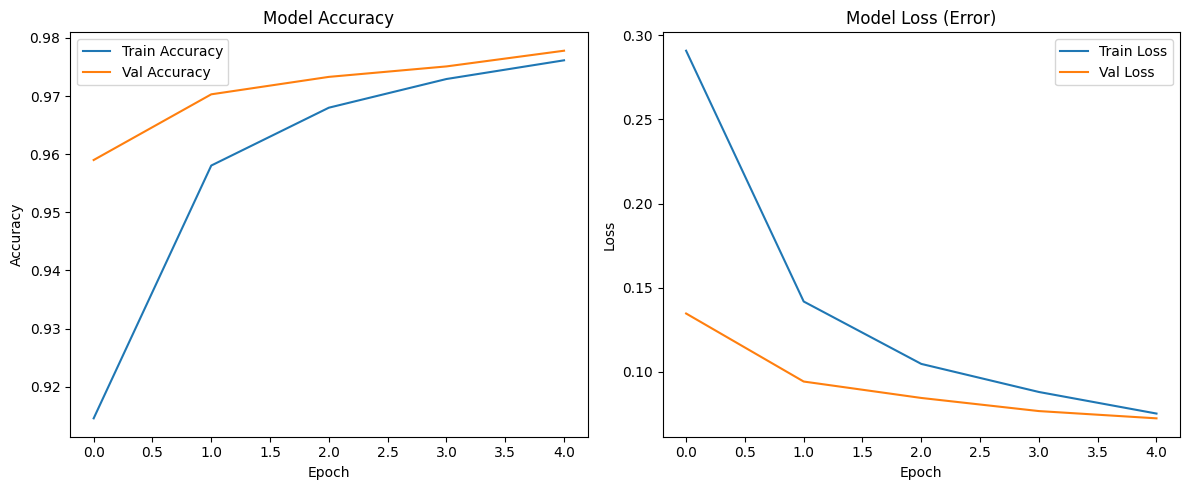

313/313 - 0s - 1ms/step - accuracy: 0.9778 - loss: 0.0724



Final Test Accuracy: 97.78%
Model saved as mnist_ann_model.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


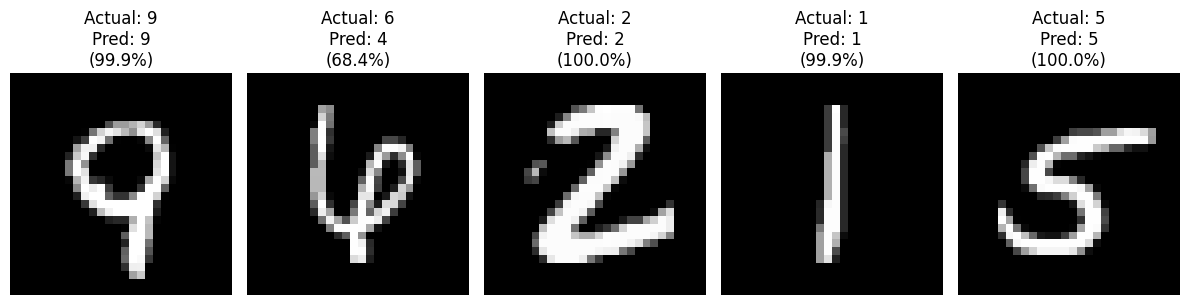

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. LOAD AND PREPROCESS DATA
print("Loading MNIST dataset...")
# MNIST is a dataset of 60,000 28x28 grayscale images of the 10 digits
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to be between 0 and 1 for faster convergence
# 
x_train, x_test = x_train / 255.0, x_test / 255.0

# 2. BUILD THE ANN MODEL
# Using a Sequential model which is a linear stack of layers
model = models.Sequential([
    # Flatten converts 28x28 2D image into a 1D array of 784 pixels
    layers.Flatten(input_shape=(28, 28)),
    
    # Hidden Layer 1: 128 neurons with ReLU activation
    layers.Dense(128, activation='relu'),
    
    # Dropout prevents overfitting by randomly setting 20% of inputs to 0
    layers.Dropout(0.2),
    
    # Output Layer: 10 neurons (one for each digit 0-9)
    # Softmax turns output into probabilities
    layers.Dense(10, activation='softmax')
])

# 3. COMPILE THE MODEL
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. TRAIN THE MODEL
print("\nStarting training...")
# Running for 5 epochs to demonstrate the learning process
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# 4. SHOW PERFORMANCE GRAPHS
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss (Error)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (Error)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 5. EVALUATE PERFORMANCE
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)
print(f'\nFinal Test Accuracy: {test_acc*100:.2f}%')



# 6. SAVE THE MODEL
model.save('mnist_ann_model.h5')
print("Model saved as mnist_ann_model.h5")

# ---------------------------------------------------------
# STEP 7: PREDICTION ON NEW (UNSEEN) DATA
# ---------------------------------------------------------
import numpy as np

# Select 5 random images from the test dataset to verify model performance
random_indices = np.random.choice(range(len(x_test)), size=5)
test_images = x_test[random_indices]
test_labels = y_test[random_indices]

# Run the inference: Model predicts the probability distribution for each image
# It returns an array of 10 probabilities (one for each digit 0-9)
predictions = model.predict(test_images)

# Set up the visualization plot
plt.figure(figsize=(12, 5))

for i in range(5):
    plt.subplot(1, 5, i+1)
    
    # Display the grayscale image
    plt.imshow(test_images[i], cmap='gray')
    
    # Use np.argmax to find the index with the highest probability (the predicted digit)
    predicted_label = np.argmax(predictions[i])
    
    # Calculate confidence percentage for the prediction
    confidence = np.max(predictions[i]) * 100
    
    # Add labels for 'Actual' vs 'Predicted' and the Confidence score
    plt.title(f"Actual: {test_labels[i]}\nPred: {predicted_label}\n({confidence:.1f}%)")
    
    # Hide axes for a cleaner visual look
    plt.axis('off')

# Adjust layout to prevent title overlapping and display the results
plt.tight_layout()
plt.show()